# TD 6 : Test de comparaison de deux moyennes de deux échantillons appariés

Christelle Gonindard, Matthais Grenié, et François Bettega

<div class="alert alert-info">

## Objectifs

- Faire la différence entre des données appariées et des données indépendantes
- Connaître les conditions d'application d'un test de comparaison de moyennes entre deux échantillons appariés
- Apprendre à mettre en œuvre un test de Student pour comparer une moyennes entre deux échantillons appariés
- Interpréter le résultat de ce test

</div>

## 1. Présentation des données

Ce jeu de données contient le résultat des taux sériques d’une hormone, exprimées en
ng⋅mL⁻¹, obtenus sur quinze patients grâce à des prélèvements sanguins, à l’aide de 2 techniques de dosage A et B.

**La question posée est la suivante : Les deux techniques de dosages diffèrent-elles ?**

Les données sont contenues dans le fichier `dosage_serique.txt` dans le dossier `data/`.

Le jeu de données comporte 3 colonnes et 15 lignes (une par patient) :

- `id` : le numéro du patient
- `a` : le résultat de dosage par la technique A
- `b` : le résultat de dosage par la technique B

Ici, ce qui nous intéresse c'est la différence entre les deux techniques, il peut être intéressant de construire une variable `d` qui soit la différence entre les deux techniques de dosage A et B.

1. Lisez les données
2. Présentez les données
3. Faites vos premières hypothèses


In [1]:
dosage = read.table("data/dosage_serique.txt", header = TRUE)

head(dosage)

,id,a,b
,<int>,<int>,<int>
1,1,22,26
2,2,27,24
3,3,12,14
4,4,33,39
5,5,14,17
6,6,52,61


[1] 42.86667

[1] 47.86667

[1] -5

[1] 15

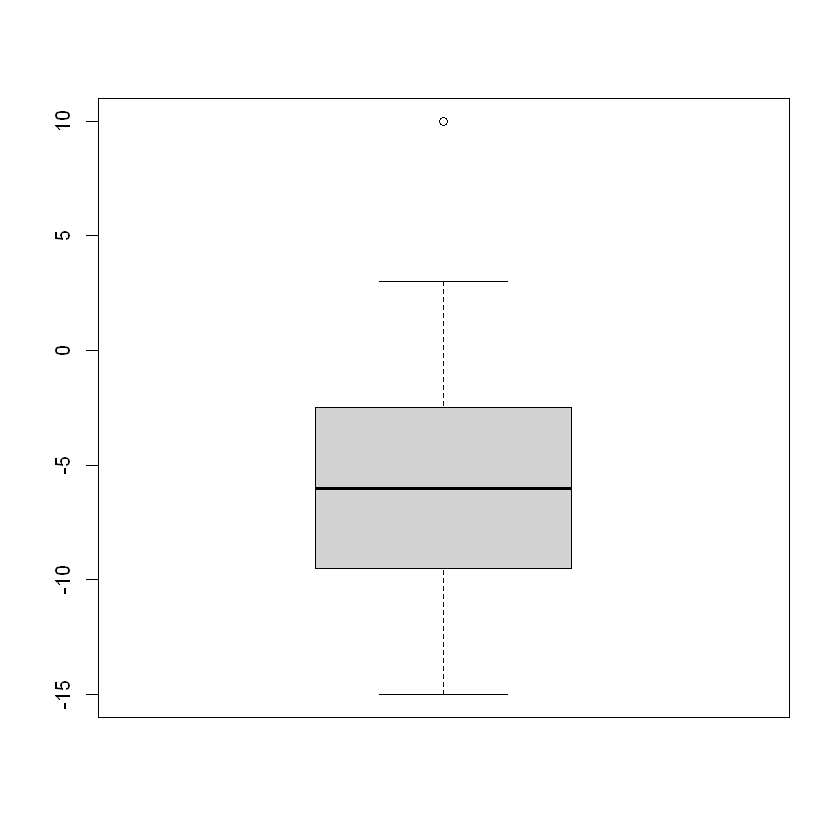

In [2]:
# Moyenne du dosage A
mean(dosage$a)

# Moyenne du dosage B
mean(dosage$b)

# Calcul des différences par patient
d = dosage$a - dosage$b

# Moyenne des différences
mean(d)

# Distribution des différences
boxplot(d)

# taille de l'échantillon 
length(d)

La moyenne obtenue pour le dosage A semble plus faible que la moyenne obtenue pour le dosage
B, cette tendance est confirmée par le boxplot représentant A-B, ou l’on peut constater que le troisième quartile est largement en dessous de 0. Tester la sur-estimation ou sous-estimation entre les deux dosages revient donc à tester que la première moyenne est effectivement plus faible que la seconde.

## 2. Principe du test de Student pour données appariées

Données appariées.

Dans le cas présent, si les deux techniques sont identiques alors les valeurs d qui représente
la différence entre les deux dosages devraient être égales à 0, ce qui revient encore à dire que la
moyenne des différences $\mu _d$ devrait également être égale à 0, ce sera donc notre hypothèse H0.
Le principe de ce test est le suivant : il va vérifier si $\mu _d$ est suffisamment éloigné de 0 avec un
certain risque d’erreur $\alpha$ pour que les deux techniques soient considérées comme significativement
différentes.
Le test calcule donc la différence entre $\mu _d$ et 0 et divise par son écart-type pour normaliser :

$$Statistique = \frac{\mu _d - 0}{\frac{S_d}{\sqrt {n}}}$$
 

## 3. Hypothèses du test 

H0 : le dosage A est égale au dosage B ce qui revient également à d = 0.

H1 : le dosage A est plus faible que le dosage B ce qui revient également à d < 0.

<div class="alert alert-danger" role="alert">

## 4. Conditions d'application

- aucune si $n \ge 30$
- si $n < 30$, il faut que la variable aléatoire différence $d$ soit distribuée normalement.

</div>

Dans ce cas, l’important avant de réaliser ce test est de vérifier que la différence entre les deux dosages suit un loi normale, car l'effectif de l'échantillon est de 15.

Nous allons réaliser un test de Shapiro sur la différence entre A et B avec les hypothèses suivantes : 

H0 : la distribution de la différence suit une loi normale.  
H1 : la distribution de la différence ne suit pas une loi normale.

In [3]:
shapiro.test(d)


	Shapiro-Wilk normality test

data:  d
W = 0.95706, p-value = 0.6414


**Conclusion** : Au seuil 5%, la pvalue>0.05, on ne peut pas rejeter l’hypothèse H0 donc la
distribution de la différence entre les deux dosages suit une loi normale. Ce qui est confirmé par
les qqplots.

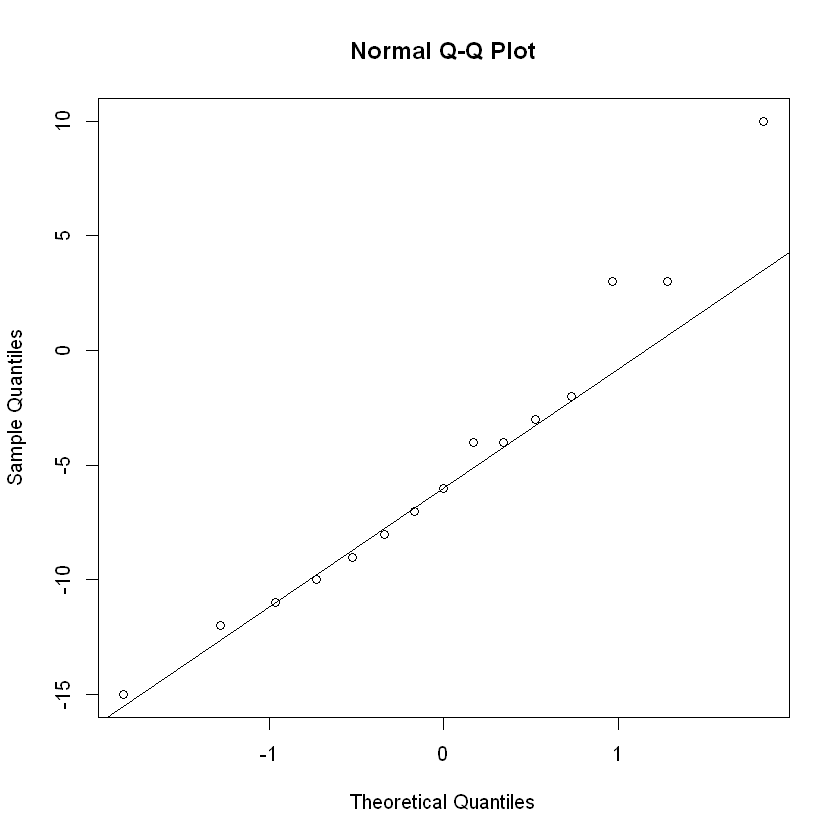

In [4]:
qqnorm(d)
qqline(d)

## 5. Réalisation du test de Student pour données appariées

Pour réaliser le test de Student avec des échantillons appariés vous pouvez utiliser la fonction `t.test.()` qui prend comme deux premiers arguments les deux échantillons et préciser l'argument `paired=` en lui donnant la valeur `TRUE` (ce qui donne `paired = TRUE`, *paired* signifie apparié en anglais).

In [5]:
t.test(dosage$a, dosage$b, paired = TRUE)


	Paired t-test

data:  dosage$a and dosage$b
t = -2.9385, df = 14, p-value = 0.01079
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -8.64944 -1.35056
sample estimates:
mean difference 
             -5 


**Conclusion** :  

Au seuil 5%, la pvalue < 0.05, on rejette l’hypothèse H0 il existe une différence
significative entre les deux dosages.

*Note : tester si les deux dosages sont différents en précisant qu'ils sont appariés avec `paired = TRUE` est identique à tester si la différence `d` est différente d'une moyenne théorique de 0*

<div class="alert alert-success">

## En résumé

Dans cette séance :

- Nous avons appris à effectuer un test de Student avec la fonction `t.test()`, en donnant les deux échantillons comme arguments puis avec l'argument `paired = TRUE` pour préciser qu'il s'agit d'échantillons appariés
- Nous avons appris les conditions d'application des tests de Student de comparaison de deux échantillons appariés :
    - si $n \geq 30$, on peut directement procéder au test ;
    - sinon, il faut vérifier la normalité de **la différence** entre les échantillons
- On peut aussi utiliser des tests bilatéraux ou unilatéraux pour comparer des échantillons appariés
- Comparer deux échantillons appariés avec un test Student revient à réaliser un test de Student pour comparer leur différence à une moyenne théorique de 0

</div>

## 6. Exercices

### Exercice 1 : somnifère dorbienal

Le dorbienal est un nouveau somnifère. Après avoir démontré la non-dangerosité de leur
molécule, le laboratoire espère prouver son efficacité. Pour cela, il lance un test sur une cohorte
de 15 personnes. Le protocole est le suivant :
1. Le temps de sommeil des 15 personnes est mesuré tous les jours pendant une semaine (période témoin).
2. Les patients sont ensuite traités pendant 15 jours avec le dorbienal.
3. Le traitement est prolongé une semaine supplémentaire pendant laquelle leur temps de sommeil est nouveau mesuré (période de traitement).

Pendant toute l’expérience, on demande aux personnes de bien respecter une heure de coucher
constante à 23h.
- Question 1 : Ce protocole vous semble-t-il approprié à l’étude de l’efficacité du dorbienal, justifiez ?
- Question 2 : Quelle caractéristique principale à ce jeu de données et quel est l’avantage principal de ce type de jeu de données ?
- Question 3 : Le dorbienal est-il efficace ? Vous répondrez pour un seuil de 1% et 5% et concluez.

Les données sont contenues dans le fichier *data_dorbienal.txt*


,id,temoin,somnifere
,<int>,<dbl>,<dbl>
1,1,7.30,7.50
2,2,6.22,7.22
3,3,6.44,5.04
4,4,7.45,8.33
5,5,6.97,7.32
6,6,6.60,7.67


[1] 15


	Shapiro-Wilk normality test

data:  d
W = 0.90731, p-value = 0.1232



	Paired t-test

data:  dorbienal$temoin and dorbienal$somnifere
t = -2.6026, df = 14, p-value = 0.01044
alternative hypothesis: true mean difference is less than 0
95 percent confidence interval:
       -Inf -0.1687405
sample estimates:
mean difference 
         -0.522 


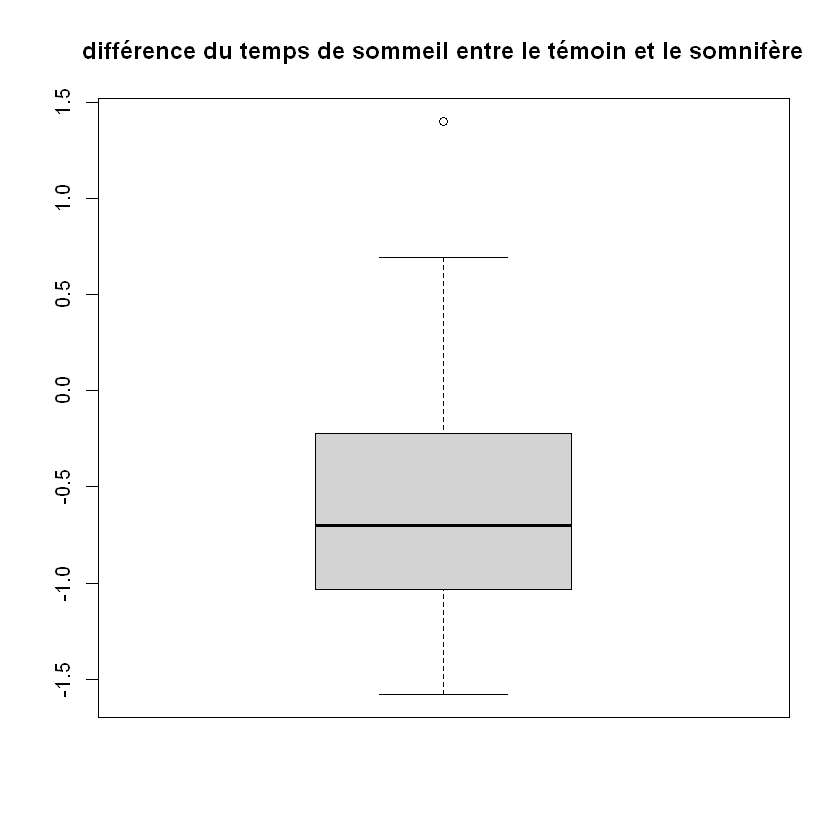

In [6]:
## Question 3 : test de comparaison de moyennes de deux échantillons 
## appariés

# Lecture des données
dorbienal=read.table("data/data_dorbienal.txt",h=T)
head(dorbienal)

# Description des données
d = dorbienal$temoin - dorbienal$somnifere
boxplot(d, main = "différence du temps de sommeil entre le témoin et le somnifère")
length(d)

# n<30 => condition application
shapiro.test(d)

# H0 : Le dorbienal et le témoin ont la même efficacité
# H1 : Le dorbienal est plus efficace que le témoin

t.test(dorbienal$temoin,dorbienal$somnifere,paired = TRUE,alternative="less")

### Exercice 2 : données appariées ou indépendantes ?

Parmi les exemples suivants les données sont-elles appariées ou indépendantes ?

1. Un laboratoire pharmaceutique souhaite tester l'efficacité d'un nouveau médicament contre l'hypertension. Son approche consiste à échantillonner la tension de quelques personnes avant et après la prise des médicaments. 

**Appariées**

2. Un laboratoire pharmaceutique souhaite tester l'efficacité d'un nouveau médicament contre l'hypertension. Son approche consiste à donner un médicament actif à un groupe de personnes et donner un placebo inactif à un autre groupe, puis comparer la tensions artérielle entre les groupes 

**Indépendantes**

3. On souhaite comparer le salaire moyen des femmes cadres et celui des hommes cadres. 

**Indépendantes**

4. 	On souhaite comparer l'efficacité de deux pommades hydratantes A et B. On applique chez des patients une pommade sur la main droite, et l'autre sur la main gauche et on mesure le résultat au bout de quelques heures. 

**Appariées**

5. On cherche à comparer deux méthodes de prélèvements (prise de sang et tests salivaires) pour estimer la prévalence du vecteur du paludisme. On applique les deux méthodes sur chaque patient d'un hôpital.

**Appariées**

6. On se demande si les pattes avant et arrière des chevreuils ont la même longueur. On mesure la différence de longueur entre pattes avant et arrière sur un échantillon de 354 chevreuils de la forêt de Fontainebleau pour déterminer si en moyenne la longueur des pattes avant et arrière est la même.

**Appariées**

7. Comparer les performances de deux machines au vu de la proportion de pièces défectueuses qu’elles produisent.


**Indépendantes**

8. Comparer la durée de vie moyenne des PME en 2008 et en 1950.


**Indépendantes**

9. On souhaite comparer le taux d’insuline est mesuré sur 30 patients recevant un placebo et 30 autres patients recevant un traitement médical. 

**Indépendantes**

10. Les données du tableau ci-dessous présentent la durée de courses de différents coureurs avant et après entrainement.

| Individuals |       Mesure       | Durée de courses (h) |
|:-----------:|:------------------:|:--------------------:|
|      1      | avant-entrainement |          1.1         |
|      1      | après-entrainement |          1.0         |
|      2      | avant-entrainement |          1.5         |
|      2      | après-entrainement |          1.6         |
|      3      | avant-entrainement |          0.8         |
|      3      | après-entrainement |          1.1         |
|      4      | avant-entrainement |          0.7         |
|      4      | après-entrainement |          0.7         |
|      5      | avant-entrainement |          1.3         |
|      5      | après-entrainement |          1.4         |



**Appariées**

11. Les données du tableau ci-dessous représentent des dosages de tacrolimus (prograf/advagraf). Cet immunomodulateur est notamment utilisé dans les greffes. C'est un médicament à marge thérapeutique étroite dont les concentrations doivent être surveillées. Voici les dosages de plusieurs patients selon la greffe dont ils ont bénéficié.
|      Groupe      | Dosage de tacrolimus ng/ml |
|:----------------:|:--------------------------:|
|   Greffe rénale  |              4             |
|   Greffe rénale  |              6             |
|   Greffe rénale  |              5             |
|   Greffe rénale  |              5             |
|   Greffe rénale  |              5             |
| Greffe cardiaque |              9             |
| Greffe cardiaque |              8             |
| Greffe cardiaque |              3             |
| Greffe cardiaque |              6             |
| Greffe cardiaque |              4             |



**Indépendantes**

12. Les données du tableau ci-dessous représentent le score de Montgomery-Åsberg Depression Rating Scale. C'est un score servant à mesurer le niveau de dépression. Les patients sont évalués avant l'initiation du traitement et après 6 mois de traitement.

| Score de dépression avant traitement | Score de dépression après traitement |
|:------------------------------------:|:------------------------------------:|
|                  35                  |                  23                  |
|                  40                  |                  15                  |
|                  30                  |                   7                  |
|                  42                  |                  43                  |
|                  50                  |                  12                  |
|                  45                  |                  39                  |

**Appariées**

13. 20 souris ont reçu un traitement X pendant 3 mois. On se pose la question à savoir si le traitement X a un impact sur le poids des souris au bout des 3 mois. Le poids des 20 souris a donc été mesuré avant et après traitement. Ce qui nous donne 20 séries de valeurs avant traitement et 20 autres séries de valeurs après traitement provenant de la mesure du poids des mêmes souris.


**Appariées**

14. Nous avons un groupe de 100 individus (50 femmes et 50 hommes) pris au hasard au sein de la population. On se pose la question à savoir si le poids moyen des femmes est significativement différent de celui des hommes?


**Indépendantes**

### Exercice 3 : Efficacité de la rééducation

Une étude évalue l'efficacité d'un programme de rééducation de 8 semaines chez 15 patients ayant subi un AVC. On mesure leur score de mobilité (échelle de 0 à 100) avant et après le programme.

Les données fournies sont les suivantes :

In [7]:
reeducation = data.frame(
  patient = 1:15,
  avant = c(45, 52, 38, 61, 48, 55, 42, 50, 58, 47, 53, 44, 49, 56, 51),
  apres = c(57, 62, 50, 70, 58, 61, 50, 55, 64, 56, 62, 56, 64, 62, 58)
)

head(reeducation)

,patient,avant,apres
,<int>,<dbl>,<dbl>
1,1,45,57
2,2,52,62
3,3,38,50
4,4,61,70
5,5,48,58
6,6,55,61


1. Calculez les statistiques descriptives pour avant, après, et les différences. Comment a évolué le score de mobilité ?

In [8]:
summary(reeducation$avant)
summary(reeducation$apres)
summary(reeducation$apres - reeducation$avant)

# => Le score a augmenté pour tous les patients

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  38.00   46.00   50.00   49.93   54.00   61.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     50      56      58      59      62      70 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  5.000   6.500   9.000   9.067  11.000  15.000 

2. Visualisez la distribution des différences

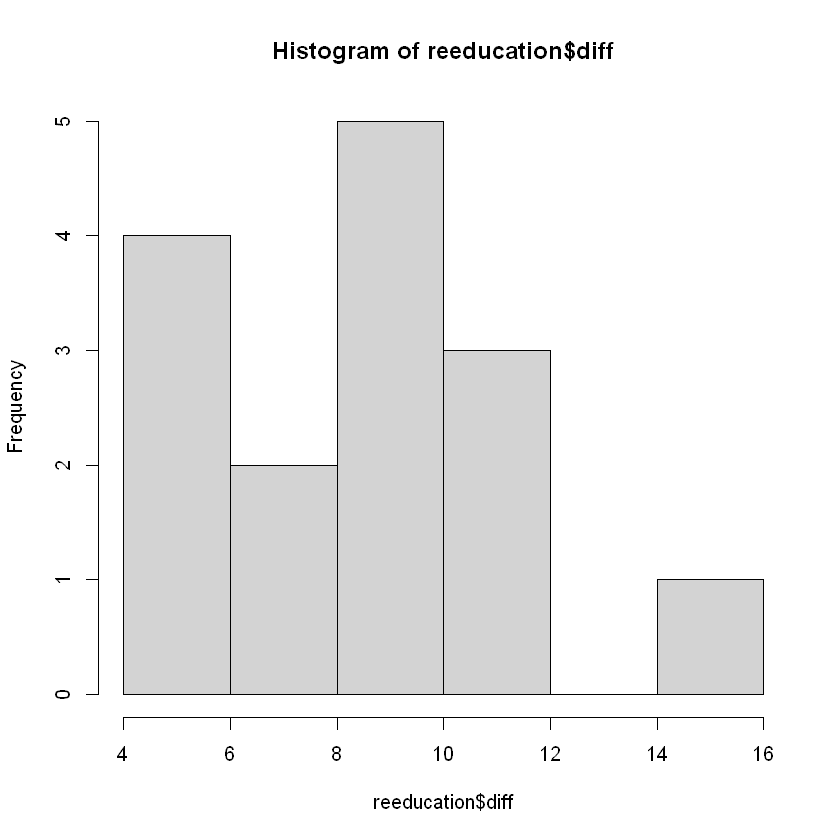

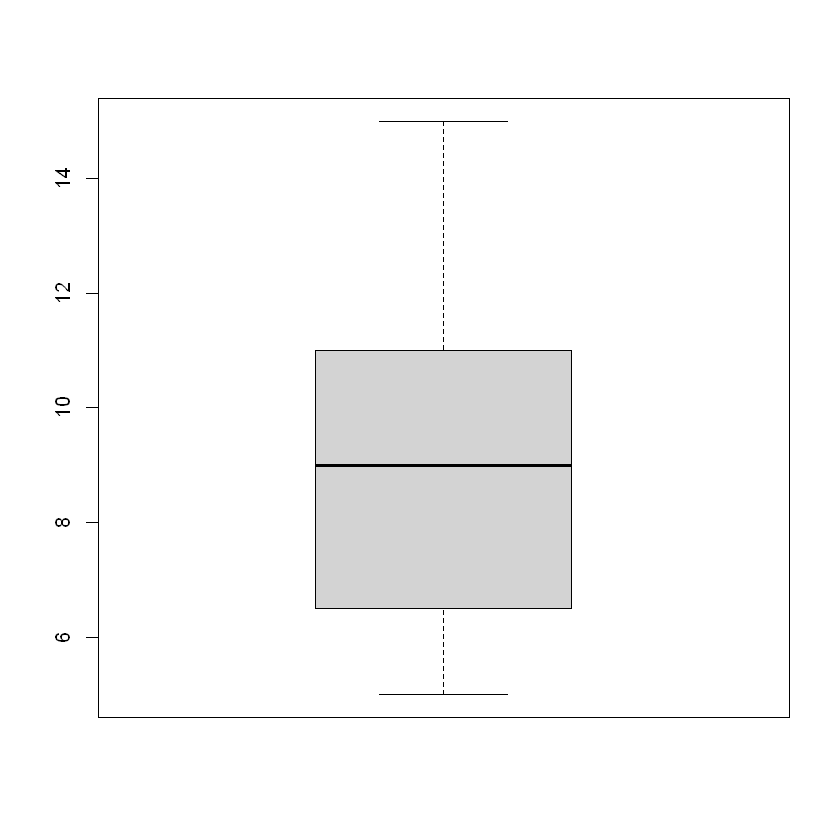

In [9]:
reeducation$diff = reeducation$apres - reeducation$avant

hist(reeducation$diff)

boxplot(reeducation$diff)

3. Vérifiez la normalité de la différence

In [10]:
shapiro.test(reeducation$diff)


	Shapiro-Wilk normality test

data:  reeducation$diff
W = 0.94653, p-value = 0.4715


4. Donnez l'intervalle de confiance à 95% de la différence du score de mobilité

In [11]:
CI <- function(x, confidence){
    alpha = 1 - confidence
    mu = mean(x)
    sigma = sd(x)
    n = length(x)
    CI_inf = mu - (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI_sup = mu + (qt(1 - alpha/2, n-1) * sigma/sqrt(n))
    CI = c(inf = CI_inf, sup = CI_sup) 
    return(CI)
}

CI(reeducation$diff, 0.95)

inf       sup 
 7.493823 10.639510

5. Calculez le score d'amélioration selon la formule suivante :  
   $$\text{\% amélioration} = \frac{\text{après} - \text{avant}}{\text{avant}} \times 100$$  
   Quel est le score moyen d'amélioration ?

In [12]:
mean((reeducation$diff / reeducation$avant) * 100)

# => En moyenne l'état des patients s'est amélioré de 18,8%

[1] 18.78801

6. On souhaite savoir si l'amélioration diffère selon le score initial.

a) Créez deux sous-groupes :

    Groupe "faible" : score initial < 50
    Groupe "élevé" : score initial ≥ 50

Combien y a-t-il de personnes dans chacun des groupes ?

b) Calculez la différence moyenne pour chaque sous-groupe

c) Créez un graphique comparant les améliorations des deux groupes

d) Que suggèrent ces résultats sur l'efficacité du programme selon le niveau initial ?

[1] 7 4

[1] 8 4

[1] 11.14286

[1] 7.25

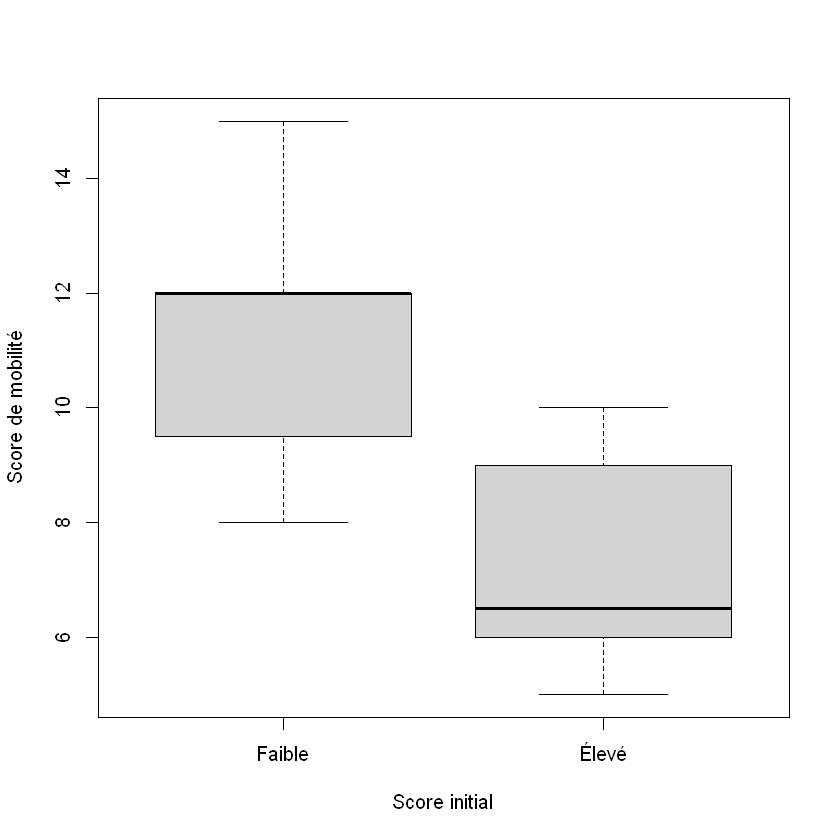

In [13]:
# a) 
groupe_faible = subset(reeducation, avant < 50)
groupe_eleve  = subset(reeducation, avant >= 50)

dim(groupe_faible)
dim(groupe_eleve)

# b)
mean(groupe_faible$diff)
mean(groupe_eleve$diff)

# c)
boxplot(groupe_faible$diff, groupe_eleve$diff, xlab = "Score initial", ylab = "Score de mobilité", names = c("Faible", "Élevé"))

# d)
# Le programme semble plus efficace sur les personnes avec un score de mobilité initialement faible